In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Set professional aesthetics for FYP report
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
colors = {'gru': '#1f77b4', 'lstm': '#2ca02c', 'cnn': '#d62728', 'dnn': '#9467bd'}

# Load the evaluation metrics
# Assuming the notebook is in root/notebook/ and data is in root/data/results/
file_path = '../data/results/final_evaluation_metrics.csv'
df = pd.read_csv(file_path, index_col=0)

# Ensure all data is numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Final Evaluation Data Loaded Successfully!")
display(df)

Final Evaluation Data Loaded Successfully!


,MAE (dB),RMSE,R2 Score,PICP (%),MPIW (dB),Params,Mem (KB),FLOPs,Inference (ms),Avg Tput (Mbps),Spectral Eff (bps/Hz),Switch Rate (%),Avg D2D Stay (s)
gru,11.83,14.52,-0.708,95.1,43.39,41665,162.8,83330,0.14,42.43,0.4243,44.58,3.4
lstm,12.06,14.78,-0.770,95.1,44.08,208001,812.5,416002,0.10,41.50,0.4150,35.82,4.5
cnn,7.28,9.17,0.303,95.9,36.51,41857,163.5,83714,0.13,47.73,0.4773,39.51,2.7
dnn,7.31,9.19,0.300,95.7,36.63,116993,457.0,233986,0.09,48.47,0.4847,42.15,2.4


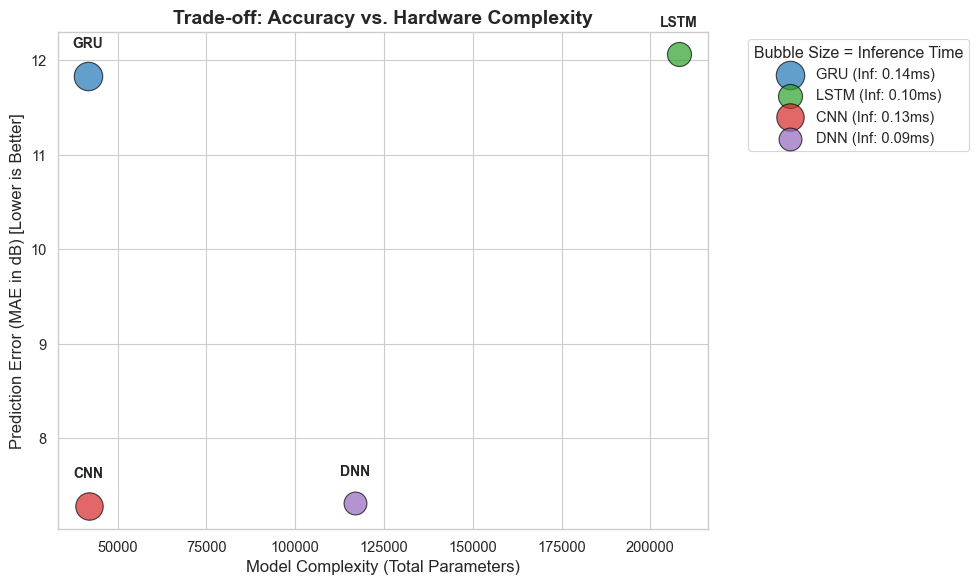

In [6]:
plt.figure(figsize=(10, 6))

# Bubble plot: X=Params, Y=MAE, Size=Inference Time
for model in df.index:
    plt.scatter(
        df.loc[model, 'Params'],  # pyright: ignore[reportArgumentType]
        df.loc[model, 'MAE (dB)'],  # pyright: ignore[reportArgumentType]
        s=df.loc[model, 'Inference (ms)'] * 3000, # Scale up bubble size for visibility # type: ignore
        alpha=0.7, 
        c=colors[model], 
        edgecolors='black',
        label=f"{model.upper()} (Inf: {df.loc[model, 'Inference (ms)']:.2f}ms)"
    )

# Annotate the points
for model in df.index:
    plt.text(
        df.loc[model, 'Params'],  # type: ignore
        df.loc[model, 'MAE (dB)'] + 0.3,  # type: ignore
        model.upper(), 
        fontsize=10, 
        ha='center', 
        fontweight='bold'
    )

plt.title('Trade-off: Accuracy vs. Hardware Complexity', fontsize=14, fontweight='bold')
plt.xlabel('Model Complexity (Total Parameters)', fontsize=12)
plt.ylabel('Prediction Error (MAE in dB) [Lower is Better]', fontsize=12)
plt.legend(title='Bubble Size = Inference Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/results/tradeoff_accuracy_complexity.png', dpi=300)
plt.show()

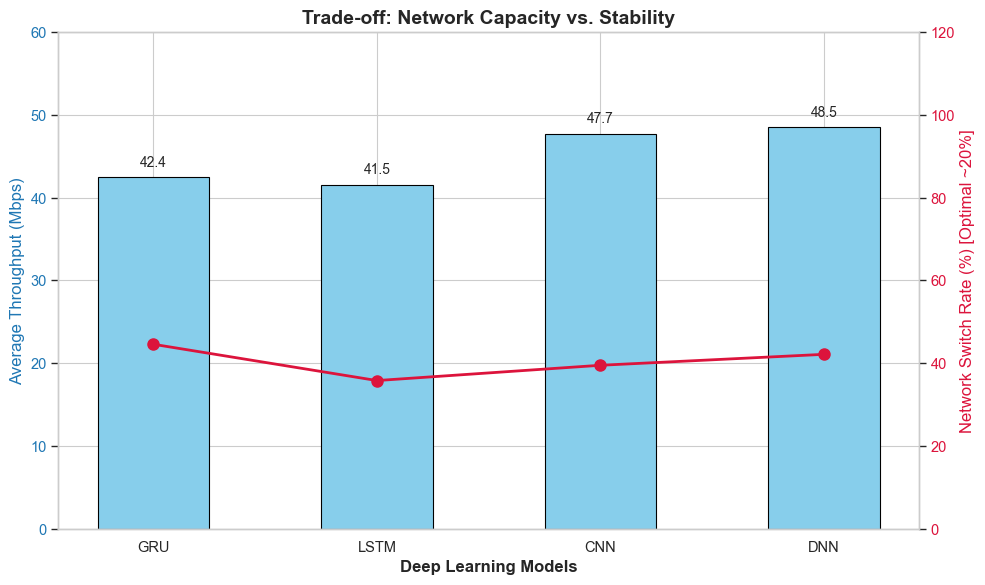

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# X-axis setup
x = np.arange(len(df.index))
width = 0.5

# Primary Axis: Average Throughput (Centered)
bars = ax1.bar(x, df['Avg Tput (Mbps)'], width, color='skyblue', edgecolor='black', label='Avg Throughput (Mbps)')
ax1.set_xlabel('Deep Learning Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Throughput (Mbps)', fontsize=12, color='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels([m.upper() for m in df.index])
ax1.tick_params(axis='y', labelcolor='tab:blue')

# === FIX: Lock Axis 1 to exactly 6 proportional ticks (0 to 60) ===
ax1.set_ylim(0, 60)
ax1.set_yticks(np.arange(0, 61, 10))

# Secondary Axis: Switch Rate (Centered)
ax2 = ax1.twinx()
line = ax2.plot(x, df['Switch Rate (%)'], color='crimson', marker='o', markersize=8, linewidth=2, label='Switch Rate (%)')
ax2.set_ylabel('Network Switch Rate (%) [Optimal ~20%]', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# === FIX: Lock Axis 2 to exactly 6 proportional ticks (0 to 120) ===
ax2.set_ylim(0, 120)
ax2.set_yticks(np.arange(0, 121, 20))
ax2.grid(False) # Keep secondary grid off so only ax1's clean grid shows

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)

plt.title('Trade-off: Network Capacity vs. Stability', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('../data/results/tradeoff_throughput_stability.png', dpi=300)
plt.show()

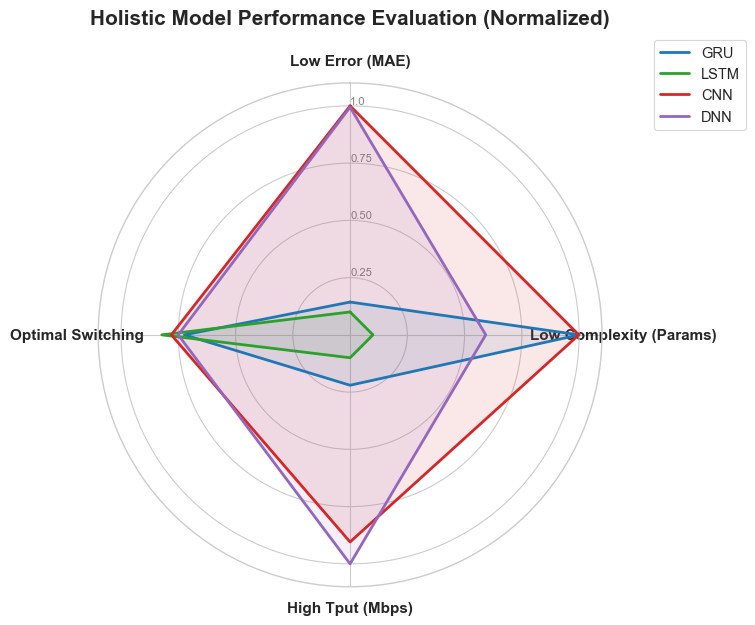

In [8]:
# Helper function to prevent polygon collapse by mapping to 0.1 - 1.0
def min_max_scale(series, invert=False):
    scaled = (series - series.min()) / (series.max() - series.min())
    if invert:
        scaled = 1 - scaled
    return 0.1 + (scaled * 0.9) # Base radius of 0.1

df_norm = pd.DataFrame(index=df.index)

# Apply safe normalization
df_norm['Low Error (MAE)'] = min_max_scale(df['MAE (dB)'], invert=True)
df_norm['Low Complexity (Params)'] = min_max_scale(df['Params'], invert=True)
df_norm['High Tput (Mbps)'] = min_max_scale(df['Avg Tput (Mbps)'], invert=False)

# Optimal switching penalty (Safe mapping)
optimal_switch = 20.0
switch_penalty = abs(df['Switch Rate (%)'] - optimal_switch) / max(optimal_switch, 100 - optimal_switch)
df_norm['Optimal Switching'] = 0.1 + ((1 - switch_penalty) * 0.9)

# Radar Chart Setup
categories = list(df_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.0"], color="grey", size=8)
plt.ylim(0, 1.1)

# Plot each model
for model in df_norm.index:
    values = df_norm.loc[model].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model.upper(), color=colors[model])
    ax.fill(angles, values, color=colors[model], alpha=0.1)

plt.title('Holistic Model Performance Evaluation (Normalized)', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../data/results/tradeoff_radar_chart.png', dpi=300)
plt.show()